## Import libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import (
    cross_validate, cross_val_predict,
)
from sklearn.metrics import classification_report, confusion_matrix, make_scorer
from xgboost import XGBClassifier

## Load data

In [22]:
BINARY_TARGET = False
INCLUDE_GEX = True

In [23]:

clinical_gex = pd.read_csv(
    '../dataset/created/clinical_gex_corrected.csv',
    low_memory=False
)
clinical_gex.columns = clinical_gex.columns.str.strip()

if BINARY_TARGET == True:
    clinical_gex = clinical_gex[clinical_gex['pfs_label'].isin([0,2])]
    clinical_gex['pfs_label'] = clinical_gex['pfs_label'].replace(2, 1)
    
groups = clinical_gex['source']

y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'index'], axis=1)

print(x.head())
print(f"\nTarget distribution:\n{y.value_counts().sort_index()}")

      sex  age AJCC_stage M_stage       LDH immunotherapy_treatment  \
0    male   26         IV     M1B  elevated                      no   
1  female   58         IV     M1A    normal                      no   
2    male   45         IV     M1A    normal                      no   
3    male   48       IIIC     NaN    normal                      no   
4    male   33         IV     M1C    normal                      no   

  pre_MAPKi_treatment  cobimetinib  dabrafenib  trametinib  ...   SLC6A20  \
0                  no            0           0           0  ...  4.384223   
1                  no            0           0           0  ...  4.385748   
2                  no            0           0           0  ...  4.384223   
3                  no            1           0           0  ...  4.385166   
4                  no            1           0           0  ...  4.385145   

     MAGEA3  TNFAIP8L2   HERC2P4     PNMA2   SLC28A3      ALAD      RHCE  \
0  6.284474   4.297704  4.262785  

In [24]:
# Clinical columns that need preprocessing
clinical_ordinal_col = ['M_stage']
clinical_categorical_cols = [
    'sex', 'AJCC_stage', 'LDH',
    'immunotherapy_treatment', 'pre_MAPKi_treatment'
]
clinical_numeric_col = ['age']

# drug_braf_cols = [
#     'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
#     'C195W', 'K601I', 'R558Q', 'MND', 'V600E', 'V600K', 'V600R'
# ]

drug_braf_cols = [
    'cobimetinib', 'trametinib', 'dabrafenib', 'vemurafenib',
    'C195W', 'K601I', 'MND', 'V600E', 'V600K', 'V600R'
]

# Gene expression columns (everything else)
all_non_gex = (
    clinical_ordinal_col + clinical_categorical_cols +
    clinical_numeric_col + drug_braf_cols
)
gex_cols = [c for c in x.columns if c not in all_non_gex]

print(f"\nClinical features: {len(clinical_ordinal_col) + len(clinical_categorical_cols) + len(clinical_numeric_col)}")
print(f"Drug/BRAF dummies: {len(drug_braf_cols)}")
print(f"Gene expression features: {len(gex_cols)}")


Clinical features: 7
Drug/BRAF dummies: 10
Gene expression features: 157


In [25]:
gex_cols

['MAGEA4',
 'MAGEA1',
 'VCX3A',
 'SV2B',
 'BAIAP2L1',
 'VCX2',
 'CKMT1A',
 'MAGEA10',
 'CTAG2',
 'GNB5',
 'CSAG2',
 'HES6',
 'VCY',
 'CTNNA3',
 'POLN',
 'CKMT1B',
 'CHRAC1',
 'SCRG1',
 'COMMD9',
 'XAGE1B',
 'PTPMT1',
 'CAMK2N1',
 'XAGE1A',
 'CD1D',
 'LOC497256',
 'PPP1R1C',
 'LHX2',
 'RBPMS2',
 'DGCR5',
 'FOXRED1',
 'TMEM80',
 'SEMA3G',
 'IL1RAPL1',
 'MAGEA12',
 'MAGEA9B',
 'SLITRK6',
 'ERICH1',
 'VCX',
 'ACP2',
 'LPAR4',
 'DRD4',
 'NLRP11',
 'TCEA3',
 'LIN28B',
 'CBS',
 'HOXA4',
 'CSAG3',
 'TRAF6',
 'PROX1',
 'SLC31A1',
 'GPR25',
 'SNAI1',
 'KBTBD8',
 'DENND2A',
 'PMEPA1',
 'TUBA8',
 'PTPRO',
 'ANO4',
 'ARHGAP27',
 'FBXW8',
 'YJEFN3',
 'TSPAN10',
 'OPRL1',
 'CLDN23',
 'RPP25',
 'FBXO36',
 'ADAMTS7',
 'HYAL4',
 'DSCR8',
 'IGDCC3',
 'ANGPT1',
 'RIMS3',
 'NUDT15',
 'PPP2R2A',
 'ADAM9',
 'EXOSC3',
 'LOC388436',
 'FAM89B',
 'ARHGEF10',
 'BCL11A',
 'AIF1L',
 'ARHGAP28',
 'MARK2',
 'SDS',
 'ZNF229',
 'POLR1E',
 'NQO1',
 'MAGEA6',
 'TIGD6',
 'DNHD1',
 'PLAG1',
 'PPP1R3F',
 'C1QTNF9B',
 'SMPD1

## Preprocessing pipeline

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

if INCLUDE_GEX == True:
    remainder='passthrough'
else:
    remainder='drop'

clinical_preprocessor = ColumnTransformer(
    transformers=[
        ('m_stage', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OrdinalEncoder(
                categories=[['M1A', 'M1B', 'M1C']],
                handle_unknown='use_encoded_value',
                unknown_value=np.nan
            )),
        ]), clinical_ordinal_col),

        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
        ]), clinical_categorical_cols),

        ('age', SimpleImputer(strategy='median'), clinical_numeric_col),
        ('drug_braf', 'passthrough', drug_braf_cols)
    ],
    remainder=remainder # gene expressions
)

x_processed = clinical_preprocessor.fit_transform(x)
x_processed = pd.DataFrame(x_processed, columns=clinical_preprocessor.get_feature_names_out())
x_processed.columns = x_processed.columns.str.split('__').str[-1]
x_processed

,M_stage,sex_female,sex_male,AJCC_stage_IIIC,AJCC_stage_IV,LDH_elevated,LDH_normal,immunotherapy_treatment_no,pre_MAPKi_treatment_no,age,...,SLC6A20,MAGEA3,TNFAIP8L2,HERC2P4,PNMA2,SLC28A3,ALAD,RHCE,SORL1,SAMD4A
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,26.0,...,4.384223,6.284474,4.297704,4.262785,5.274553,3.888714,5.890571,4.040785,5.674289,5.297394
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,58.0,...,4.385748,6.862708,4.276909,4.483725,5.299898,3.846581,6.463356,4.002404,5.224376,5.490748
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,45.0,...,4.384223,5.626812,4.337528,4.258745,5.309691,3.851291,5.914027,4.059241,6.147752,5.007887
3,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,48.0,...,4.385166,4.948698,4.413269,4.219724,5.321396,3.871215,5.981546,4.049749,5.336090,5.050745
4,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,33.0,...,4.385145,6.264354,4.295142,4.685055,5.301190,3.859265,6.369937,4.339283,6.487131,5.317965
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,61.0,...,4.346945,5.594205,4.584799,4.459048,4.900091,4.007242,5.833042,4.025481,6.240612,4.880488
130,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,65.0,...,4.355378,5.748913,4.317679,4.454954,5.023566,4.049761,6.137828,4.035033,5.673329,4.936892
131,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,51.0,...,4.350000,6.238433,4.345152,4.450419,5.334232,3.975395,6.391950,4.049596,5.553562,5.072633
132,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,41.0,...,4.345396,5.333456,5.124939,4.451894,5.356338,4.047086,6.012168,4.011786,5.556268,4.905885


In [27]:
x = x_processed.copy()

In [28]:
# Check for non-numeric columns
non_numeric_cols = x.select_dtypes(include=['object']).columns
print(f"Non-numeric columns: {non_numeric_cols}")

# Inspect the content of the problematic column
for col in non_numeric_cols:
    print(f"Unique values in {col}: {x[col].unique()[:5]}")

Non-numeric columns: Index([], dtype='object')


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, RFECV

rfecv = RFECV(
    estimator=RandomForestClassifier(random_state=42), 
    step=1,
    cv=5
)

rfe = RFE(
    estimator=RandomForestClassifier(random_state=42), 
    step=1, 
    n_features_to_select=15
)

x_rfe = rfe.fit_transform(x, y)
x_rfe = pd.DataFrame(x_rfe, columns=rfe.get_feature_names_out())
x_rfe

,BAIAP2L1,HES6,SCRG1,COMMD9,SLC31A1,TUBA8,FBXW8,ADAM9,ARHGAP28,C1QTNF9B,ZNF691,SURF6,ABHD6,TRAF3,CHAF1B
0,5.647183,6.732841,5.481653,6.406236,6.195430,4.129544,5.266618,6.149097,4.599877,4.609258,4.782291,6.487541,5.777972,5.026490,5.788838
1,5.775339,6.791110,5.440255,6.597136,6.965004,6.042642,5.392916,6.067270,4.554162,4.625787,4.918283,6.701406,6.047259,4.815795,5.774022
2,5.590498,6.715236,5.771732,6.378779,6.268040,3.969837,5.133803,6.535290,4.646914,4.607943,4.872972,6.422925,5.764098,5.271509,5.611036
3,5.721581,6.731672,5.464607,6.471073,6.450474,3.844245,5.104035,6.485873,5.165232,4.603294,4.803268,6.453900,5.770349,4.915295,5.448097
4,5.731831,6.758138,6.329743,6.598261,6.404945,3.941916,5.391194,6.219228,4.755140,4.611543,5.119639,6.507163,6.009336,4.383612,5.658816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129,5.182387,5.942368,5.865902,6.315506,6.175912,4.038157,5.111876,6.143030,4.920386,4.500470,5.009226,6.288400,5.529386,4.975759,5.433795
130,5.355619,6.707333,6.801137,6.976215,6.149374,5.609628,5.182770,5.289886,4.899970,4.656645,5.093393,6.432592,5.929540,4.970269,5.710225
131,5.163784,6.005457,5.377972,7.149198,6.515342,4.065472,5.010147,5.234681,4.844378,4.518215,5.006334,6.638345,6.393376,4.808946,6.001330
132,5.059882,6.401619,4.366692,6.662338,6.685232,4.052722,5.105821,6.089778,4.854887,4.452259,5.136747,6.284549,5.880190,4.911048,5.618806


In [30]:
print("Selected genes:", x_rfe.columns.tolist())

Selected genes: ['BAIAP2L1', 'HES6', 'SCRG1', 'COMMD9', 'SLC31A1', 'TUBA8', 'FBXW8', 'ADAM9', 'ARHGAP28', 'C1QTNF9B', 'ZNF691', 'SURF6', 'ABHD6', 'TRAF3', 'CHAF1B']


## Hyperparams tuning

In [31]:
CLASSIFIER = 'xgboost'
CV = 'skf'
x = x_rfe.copy()

In [32]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import LeaveOneGroupOut

logo = LeaveOneGroupOut()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if CLASSIFIER == 'xgboost':
    if BINARY_TARGET:
        clf = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            random_state=42,
        )
    else:
        clf = XGBClassifier(
            objective='multi:softprob',
            num_class=3,
            eval_metric='mlogloss',
            random_state=42,
        )
elif CLASSIFIER == 'lr':
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            max_iter=5000,
            random_state=42,
        ))
    ])
    

def objective(trial):
    if CLASSIFIER == 'xgboost':
        params = {
            'n_estimators': 200,
            'max_depth': trial.suggest_int('max_depth', 1, 3),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),  # Force higher L2 regularization to keep the model conservative.
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        }
    
    elif CLASSIFIER == 'lr':
        params = {
            'clf__C': trial.suggest_float('clf__C', 0.0001, 0.01, log=True), # Very small C = Strong penalty
        }

    clf.set_params(**params)

    if CV == 'logo':
        scores = cross_val_score(clf, x, y, groups=groups, cv=logo, scoring='f1_macro', n_jobs=-1)
    elif CV == 'skf':
        scores = cross_val_score(clf, x, y, cv=skf, scoring='f1_macro', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

print("Best params:", study.best_params)
print("Best CV F1 macro:", study.best_value)

/Users/buudinhha/PycharmProjects/internship-m2-melanoma/main/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-22 16:28:51,426] A new study created in memory with name: no-name-b7c75597-f21d-48c4-975b-250601f850f8
[I 2026-04-22 16:28:53,387] Trial 0 finished with value: 0.6096350055173584 and parameters: {'max_depth': 1, 'learning_rate': 0.01871488602499255, 'subsample': 0.5594198123278685, 'colsample_bytree': 0.6826064186397007, 'reg_alpha': 0.010664357256362535, 'reg_lambda': 8.978732928301024, 'min_child_weight': 7, 'gamma': 1.6275492734832364}. Best is trial 0 with value: 0.6096350055173584.
[I 2026-04-22 16:28:55,062] Trial 1 finished with value: 0.26456996148908857 and parameters: {'max_depth': 3, 'learning_rate': 0.018590181521047654, 'subsample': 0.8118294122287065, 'colsample_bytr

Best params: {'max_depth': 1, 'learning_rate': 0.030065650257458262, 'subsample': 0.5950438850441618, 'colsample_bytree': 0.5510331796892125, 'reg_alpha': 0.012419964637917048, 'reg_lambda': 8.551650560960432, 'min_child_weight': 7, 'gamma': 0.2961273585007496}
Best CV F1 macro: 0.7126939221436375


## Run models

Test ROC-AUC (OVO) : 0.843 ± 0.078
Test Macro F1      : 0.713 ± 0.097
Train ROC-AUC (OVO): 0.956 ± 0.008
Train Macro F1     : 0.842 ± 0.024


              precision    recall  f1-score   support

  Short resp       0.72      0.96      0.82        70
Intermediate       0.88      0.70      0.78        30
   Long resp       0.82      0.41      0.55        34

    accuracy                           0.76       134
   macro avg       0.81      0.69      0.72       134
weighted avg       0.78      0.76      0.74       134



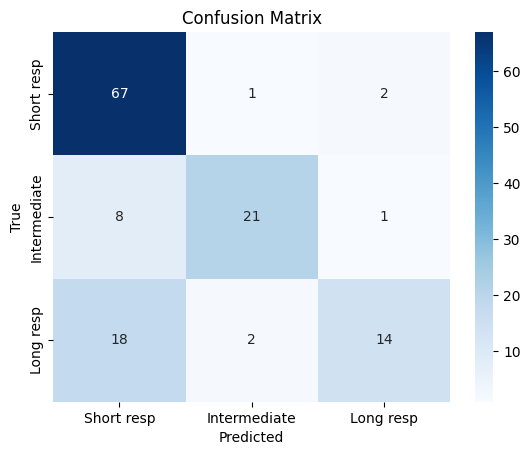

In [33]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

clf.set_params(**study.best_params)

if CV == 'logo':
    results = cross_validate(
        clf, x, y,
        cv=logo,
        groups=groups,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    y_pred = cross_val_predict(
        clf, x, y, 
        cv=logo,
        groups=groups,
        n_jobs=-1
    )
elif CV == 'skf':
    results = cross_validate(
        clf, x, y,
        cv=skf,
        scoring=['roc_auc_ovo', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    y_pred = cross_val_predict(
        clf, x, y, cv=skf,
        n_jobs=-1
    )

if BINARY_TARGET == True:
    target_names = ['Short resp', 'Long resp']
else:
    target_names = ['Short resp', 'Intermediate', 'Long resp']

print(f"Test ROC-AUC (OVO) : {results['test_roc_auc_ovo'].mean():.3f} ± {results['test_roc_auc_ovo'].std():.3f}")
print(f"Test Macro F1      : {results['test_f1_macro'].mean():.3f} ± {results['test_f1_macro'].std():.3f}")
print(f"Train ROC-AUC (OVO): {results['train_roc_auc_ovo'].mean():.3f} ± {results['train_roc_auc_ovo'].std():.3f}")
print(f"Train Macro F1     : {results['train_f1_macro'].mean():.3f} ± {results['train_f1_macro'].std():.3f}")

print("\n")
print(classification_report(
    y, y_pred,
    target_names=target_names
))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names,
            yticklabels=target_names,
            cmap='Blues')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## Explanability

### SHAP values

In [34]:
import shap
shap.initjs()

model = clf.fit(x, y)

if CLASSIFIER == 'lr':
    x_shap = model.named_steps['scaler'].transform(x)
    x_shap = pd.DataFrame(x_shap, columns=x.columns)
    explainer = shap.LinearExplainer(clf.named_steps['clf'], x_shap)

elif CLASSIFIER == 'xgboost':
    x_shap = pd.DataFrame(x, columns=x.columns)
    explainer = shap.TreeExplainer(model, x_shap)
    
shap_values = explainer(x_shap)
np.shape(shap_values.values)

(134, 15, 3)

### Waterfall plot

In [35]:
OBS = 0
CLASS = 0
sv1 = shap_values[OBS, :, CLASS]      

predicted_class = int(model.predict(x)[OBS])
print(f'Predicted class of observation {OBS}, class {CLASS}: {predicted_class}')

Predicted class of observation 0, class 0: 0


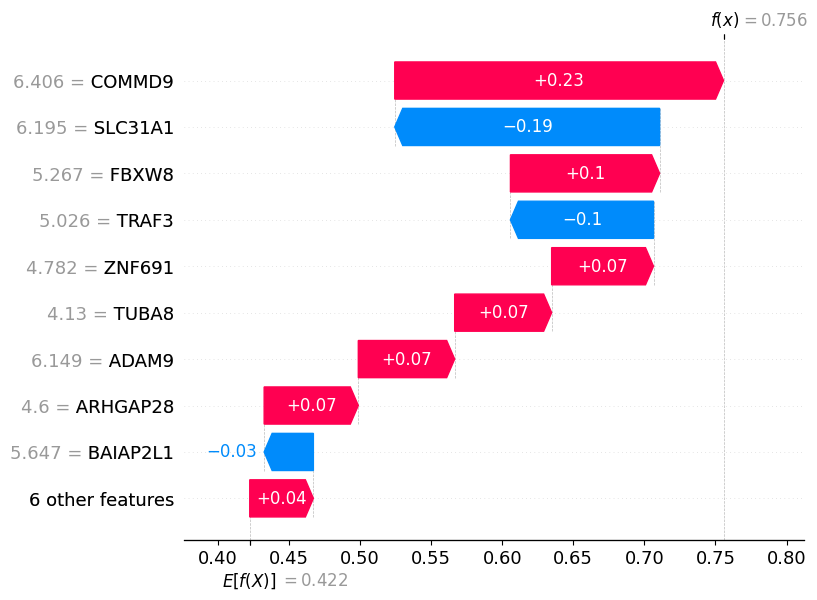

In [36]:
shap.plots.waterfall(sv1)

### Force plot

In [37]:
shap.plots.force(sv1)

### Stacked force plot

In [38]:
sv_all = shap_values[:, :, CLASS]     

shap.plots.force(sv_all)


### Absolute mean SHAP

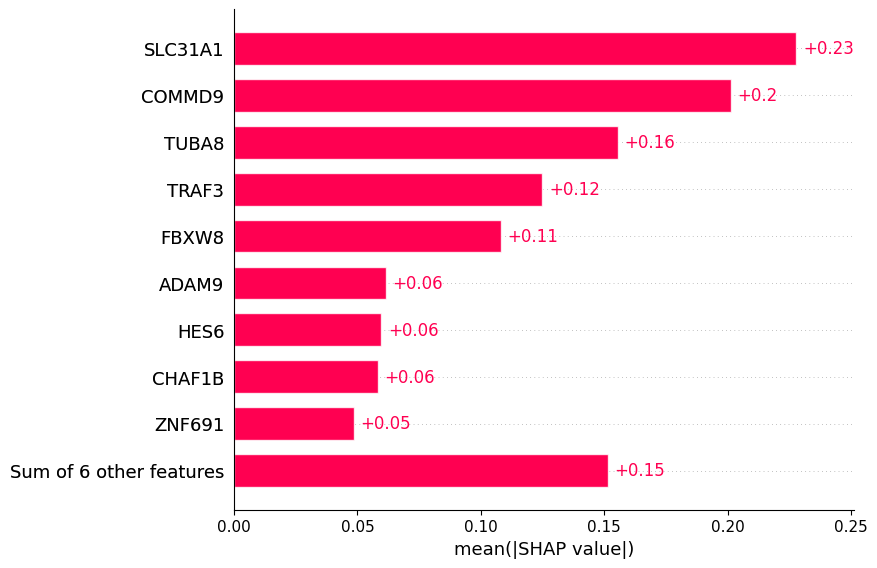

In [39]:
shap.plots.bar(sv_all)

### Beeswarm plot

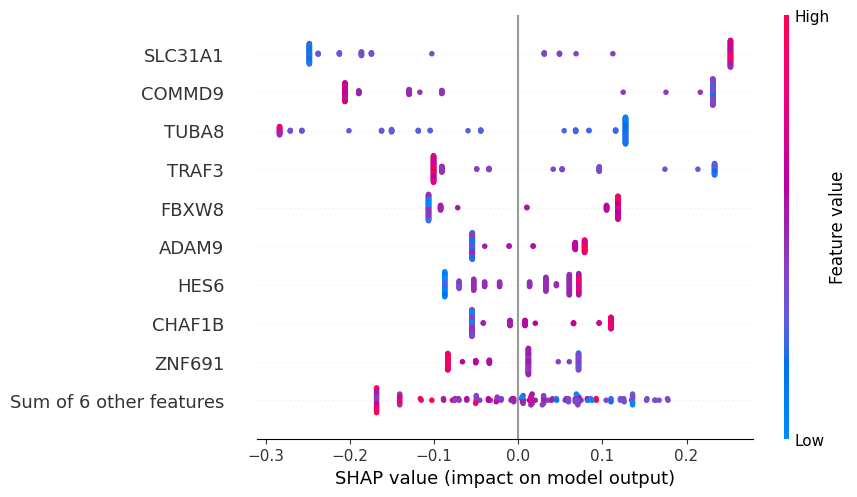

In [40]:
shap.plots.beeswarm(sv_all)

### Dependence plots

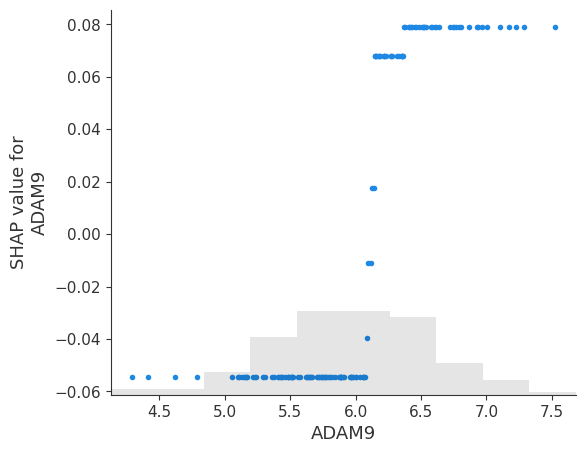

In [41]:
shap.plots.scatter(sv_all[:, 'ADAM9'])

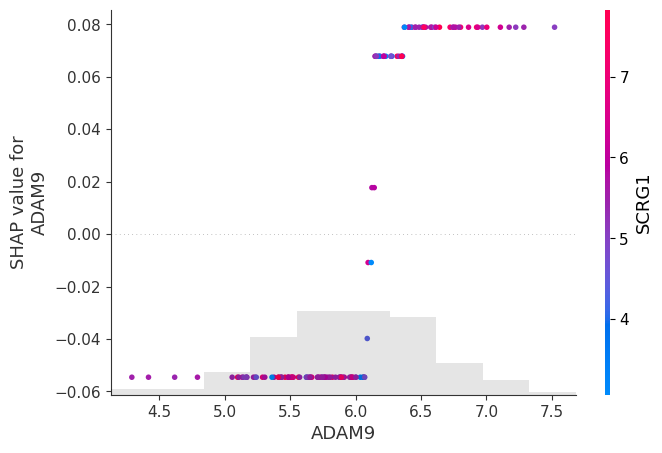

In [42]:
shap.plots.scatter(
    shap_values=sv_all[:, 'ADAM9'],
    color=sv_all[:, 'SCRG1']
)

### Heatmap plot

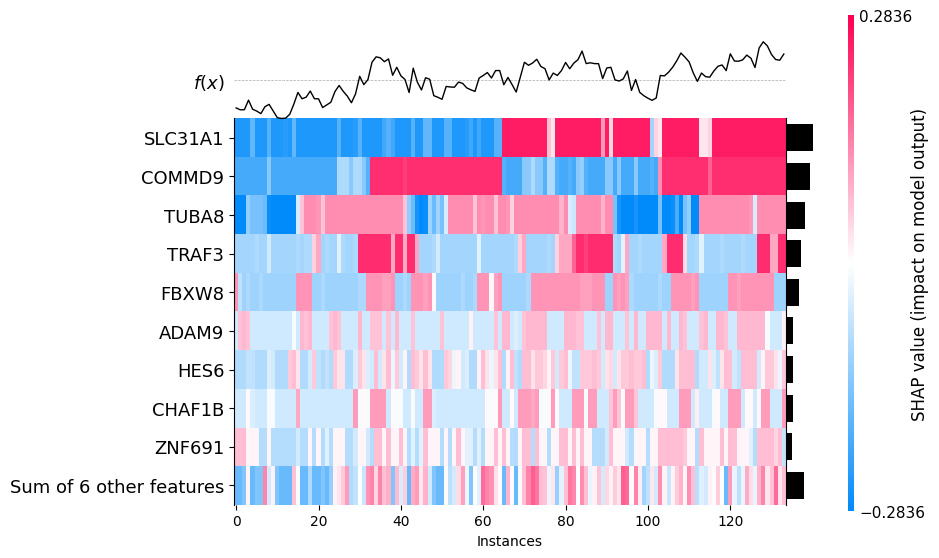

<Axes: xlabel='Instances'>

In [43]:
shap.plots.heatmap(sv_all)

### Violin plot

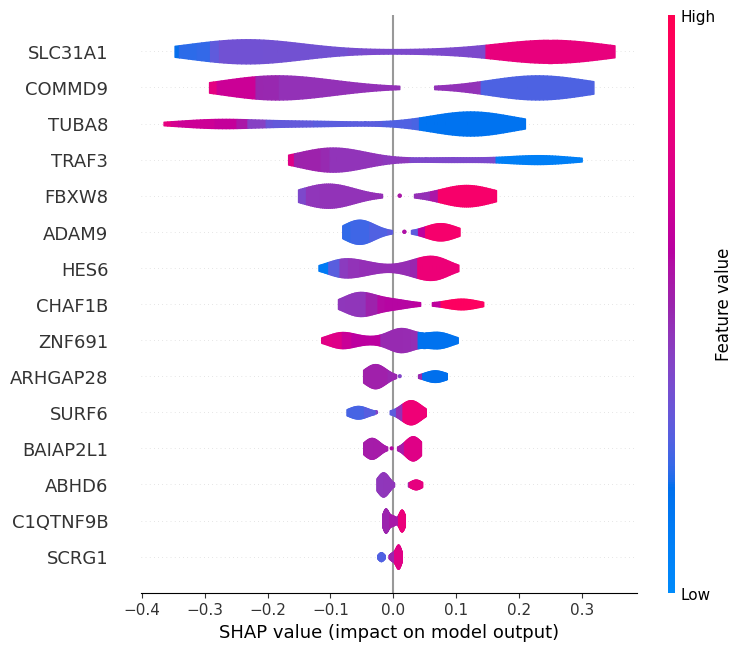

In [44]:
shap.plots.violin(sv_all)